# dinomics: DINO feature extraction

Extract **CLS (slice)** and **patch** embeddings from 2D/3D medical images with DINOv2 or DINOv3.

This notebook uses the bundled MRI (T2-weighted + ROI mask), CT (volume + label map), and chest X-ray (2D DICOM, **no mask**) examples.
MRI and CT enable a **square crop centered on the mask centroid**. Depth keeps only slices that contain mask. If the mask does not fit the requested `crop_size`, the square expands and out-of-image voxels are zero-padded. The X-ray uses the full field of view.

Patch tokens are visualized with the same PCA recipe as `dinov2-radiomics/dinov2_feature_extraction.ipynb`:
PCA to 3 components (whitened) → sigmoid → nearest-neighbor upsample → overlay.

In [45]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

from dinomics import DinoExtractor, extract_features, load_config, plot_pca_features
from dinomics.io import align_mask, load_volume
from dinomics.preprocess import apply_intensity, crop_centered_on_mask

ROOT = Path("..").resolve()
MRI_IMAGE = ROOT / "example_data/MRI/10000_1000000_t2w.mha"
MRI_MASK = ROOT / "example_data/MRI/10000_1000000.nii.gz"
CT_IMAGE = ROOT / "example_data/CT/volume-10.nii"
CT_MASK = ROOT / "example_data/CT/labels-10.nii"
XRAY_IMAGE = ROOT / "example_data/X-ray/dx-chest-varepop-apollo-instance.dcm"
CONFIG_DINOV2 = ROOT / "configs/dinov2.yaml"
CONFIG_CT = ROOT / "configs/ct.yaml"
CONFIG_DEFAULT = ROOT / "configs/default.yaml"

print("Repo root:", ROOT)

Repo root: /home/alex_calado/projects/dinomics


## Config

All model and extraction parameters live in a YAML or TOML file. `load_config` returns a dataclass you can still edit in-memory before extraction.

In [46]:
config = load_config(CONFIG_DINOV2)
print("Model:", config.model.name)
print("Feature type:", config.model.feature_type)
print("Image size:", config.model.image_size)
print("Device:", config.model.device)
print(config.to_dict())

Model: facebook/dinov2-base
Feature type: dinov2
Image size: 224
Device: auto
{'model': {'name': 'facebook/dinov2-base', 'feature_type': 'dinov2', 'image_size': 224, 'device': 'auto', 'n_register_tokens': 0, 'do_center_crop': False}, 'intensity': {'clip_percentiles': None, 'window': None}, 'extraction': {'apply_image_mask': True, 'apply_patch_mask': True, 'skip_empty_slices': True, 'slice_axis': 0, 'slice_indices': None, 'slice_step': 1, 'max_slices': None, 'crop_to_mask': True, 'crop_size': 128, 'min_mask_pixels': 1, 'remove_small_holes': True, 'hole_area_threshold': 512, 'mirror_mask_y': True}, 'output': {'include_flat_patches': False}}


## MRI volume (slice-wise)

The T2-weighted volume is processed slice by slice. The `.nii.gz` mask is resampled onto the image grid if needed. With `crop_to_mask: true` the extractor takes a square window around the mask centroid (padding if the window leaves the FOV), zeros background patches, and skips empty slices.

In [47]:
mri = load_volume(MRI_IMAGE)
mri_mask = load_volume(MRI_MASK)
print(f"MRI image: {mri.array.shape}  spacing={mri.spacing}")
print(f"MRI mask:  {mri_mask.array.shape}  unique={np.unique(mri_mask.array)}")

MRI image: (31, 640, 640)  spacing=(0.28125, 0.28125, 3.2999999825580133)
MRI mask:  (31, 640, 640)  unique=[0 1]


In [48]:
extractor = DinoExtractor.from_config(config)
mri_features = extractor.extract(MRI_IMAGE, mask=MRI_MASK)

print("CLS embeddings:              ", mri_features.cls_embeddings.shape)
print("Patch embeddings:            ", mri_features.patch_embeddings.shape)
print("Max-pooled patch embeddings: ", mri_features.patch_embeddings_maxpooled.shape)
print("Patch mask:                  ", None if mri_features.patch_mask is None else mri_features.patch_mask.shape)
print("Processed slice indices:     ", mri_features.slice_indices)
print("Crop:                        ", mri_features.metadata.get("crop_region"))

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

CLS embeddings:               (12, 768)
Patch embeddings:             (12, 16, 16, 768)
Max-pooled patch embeddings:  (12, 768)
Patch mask:                   (12, 16, 16)
Processed slice indices:      [ 8  9 10 11 12 13 14 15 16 17 18 19]
Crop:                         {'crop_region': (245, 434, 184, 373), 'centroid': (339, 278), 'crop_size': 189, 'padded': False, 'valid_slice_indices': [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]}


### PCA visualization of MRI patch tokens

The first panel is the slice **before** the crop. The other panels use the cropped / masked image; zero pixels and zero patches are left transparent.

PCA is fit on the **displayed slice** only (non-zero patches).

Visualizing cropped slice 6 (original z=14, size=187, centroid=(339, 279), padded=False)


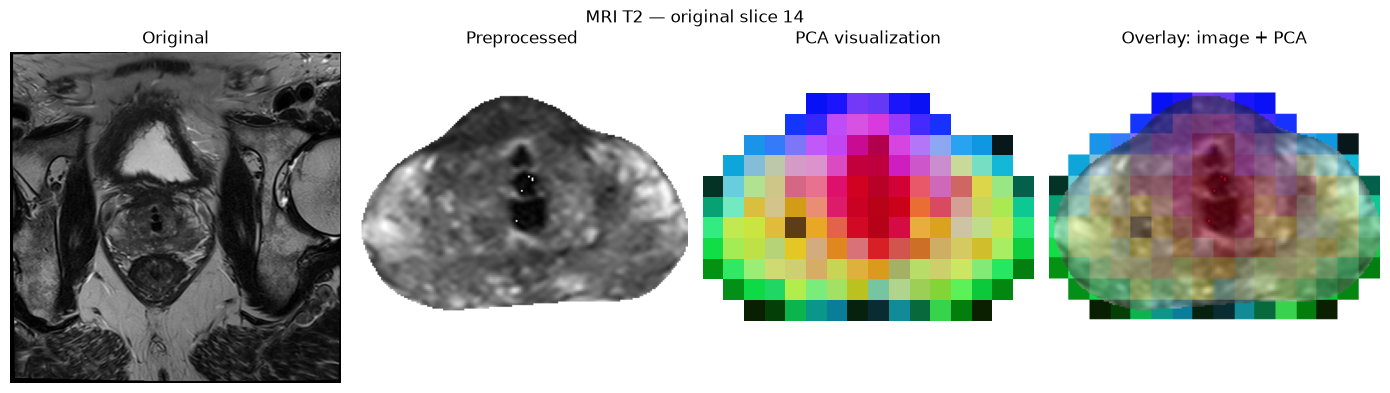

PCA map shape: (16, 16, 3)  visible range: [0.003, 0.997]


In [49]:
aligned_mask = align_mask(mri_mask, mri)
cropped_mri, cropped_mri_mask, _, mri_crop = crop_centered_on_mask(
    mri.array,
    (aligned_mask.array > 0).astype(np.uint8),
    crop_size=config.extraction.crop_size,
    min_mask_pixels=config.extraction.min_mask_pixels,
)
counts = (cropped_mri_mask > 0).sum(axis=(1, 2))
mri_local_idx = int(counts.argmax())
vis_idx = mri_crop["valid_slice_indices"][mri_local_idx]
result_idx = int(np.where(mri_features.slice_indices == vis_idx)[0][0])

print(
    f"Visualizing cropped slice {mri_local_idx} (original z={vis_idx}, "
    f"size={mri_crop['crop_size']}, centroid={mri_crop['centroid']}, padded={mri_crop['padded']})"
)

fig, axes, heatmap = plot_pca_features(
    cropped_mri[mri_local_idx],
    mri_features.patch_embeddings[result_idx],
    original_slice=mri.array[vis_idx],
    mask_slice=cropped_mri_mask[mri_local_idx],
    title=f"MRI T2 — original slice {vis_idx}",
)
plt.show()

finite = heatmap[np.isfinite(heatmap)]
print(f"PCA map shape: {heatmap.shape}  visible range: [{finite.min():.3f}, {finite.max():.3f}]")

CLS embeddings across slices — sanity check that neighbouring slices are similar.

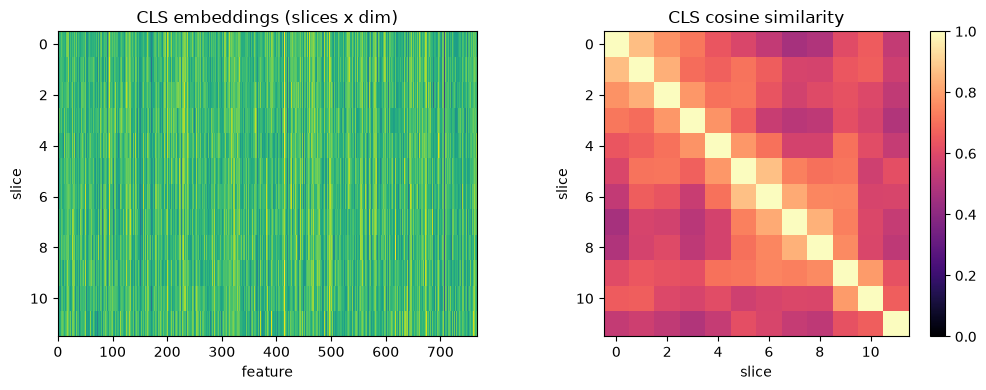

In [50]:
cls = mri_features.cls_embeddings
cls_norm = cls / (np.linalg.norm(cls, axis=1, keepdims=True) + 1e-8)
similarity = cls_norm @ cls_norm.T

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cls, aspect="auto", interpolation="nearest")
axes[0].set_title("CLS embeddings (slices x dim)")
axes[0].set_xlabel("feature")
axes[0].set_ylabel("slice")
im = axes[1].imshow(similarity, vmin=0, vmax=1, cmap="magma")
axes[1].set_title("CLS cosine similarity")
axes[1].set_xlabel("slice")
axes[1].set_ylabel("slice")
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.tight_layout()
plt.show()

## CT volume

`configs/ct.yaml` applies a soft-tissue window `[40, 400]` HU and the same centroid-centered square crop (`crop_size: null` auto-fits the mask; expands and pads if needed). Depth keeps only slices that contain mask.

In [ ]:
ct_config = load_config(CONFIG_CT)
print(ct_config.to_dict())

ct = load_volume(CT_IMAGE)
ct_mask = load_volume(CT_MASK)

print(f"CT image: {ct.array.shape}  spacing={ct.spacing}")
print(f"CT labels unique: {np.unique(ct_mask.array)}")

{'model': {'name': 'facebook/dinov2-base', 'feature_type': 'dinov2', 'image_size': 448, 'device': 'auto', 'n_register_tokens': 0, 'do_center_crop': False}, 'intensity': {'clip_percentiles': None, 'window': [40, 400]}, 'extraction': {'apply_image_mask': True, 'apply_patch_mask': True, 'skip_empty_slices': True, 'slice_axis': 0, 'slice_indices': None, 'slice_step': 1, 'max_slices': None, 'crop_to_mask': True, 'crop_size': None, 'min_mask_pixels': 1, 'remove_small_holes': False, 'hole_area_threshold': 512, 'mirror_mask_y': False}, 'output': {'include_flat_patches': False}}
CT image: (501, 512, 512)  spacing=(0.76953125, 0.76953125, 1.0)
CT labels unique: [0 1]


In [ ]:
ct_extractor = DinoExtractor.from_config(ct_config)
ct_features = ct_extractor.extract(CT_IMAGE, mask=CT_MASK, label_mask=CT_MASK)

print("CLS embeddings:   ", ct_features.cls_embeddings.shape)
print("Patch embeddings: ", ct_features.patch_embeddings.shape)
print("Patch labels:     ", None if ct_features.patch_labels is None else ct_features.patch_labels.shape)
print("Slices processed: ", len(ct_features.slice_indices))
print("Crop:             ", ct_features.metadata.get("crop_region"))

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

TypeError: Cannot build a SimpleITK image from <class 'dinomics.io.Volume'>

Visualizing cropped slice 151 (original z=446, size=445, centroid=(277, 138), padded=True)


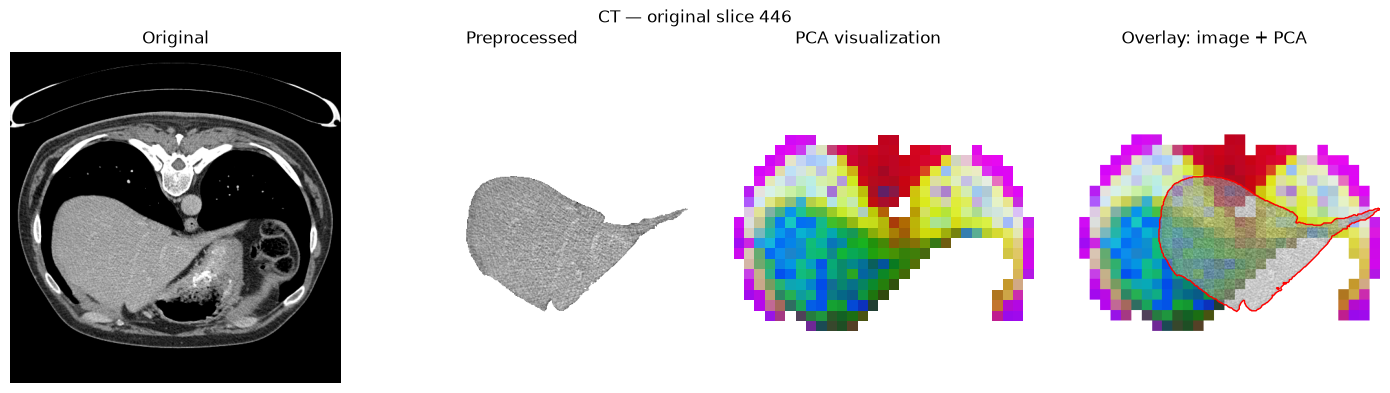

In [53]:
aligned_ct_mask = align_mask(ct_mask, ct)
cropped_ct, cropped_mask, extras, ct_crop = crop_centered_on_mask(
    ct.array,
    (aligned_ct_mask.array > 0).astype(np.uint8),
    crop_size=ct_config.extraction.crop_size,
    min_mask_pixels=ct_config.extraction.min_mask_pixels,
    extras=[aligned_ct_mask.array],
)
cropped_labels = extras[0]
windowed = apply_intensity(cropped_ct, ct_config.intensity)

counts = (cropped_mask > 0).sum(axis=(1, 2))
local_idx = int(counts.argmax())
orig_slice = ct_crop["valid_slice_indices"][local_idx]
result_idx = int(np.where(ct_features.slice_indices == orig_slice)[0][0])

print(
    f"Visualizing cropped slice {local_idx} (original z={orig_slice}, "
    f"size={ct_crop['crop_size']}, centroid={ct_crop['centroid']}, padded={ct_crop['padded']})"
)

fig, axes, heatmap = plot_pca_features(
    windowed[local_idx],
    ct_features.patch_embeddings[result_idx],
    original_slice=apply_intensity(ct.array[orig_slice], ct_config.intensity),
    mask_slice=cropped_mask[local_idx],
    label_slice=cropped_labels[local_idx],
    title=f"CT — original slice {orig_slice}",
)
plt.show()

## Chest X-ray (2D, no mask)

`example_data/X-ray/dx-chest-varepop-apollo-instance.dcm` is a single-frame chest radiograph. No ROI is passed. `configs/default.yaml` keeps `crop_to_mask: false`, so the **full field of view** is used. Because the frame is not square, each slice is **letterboxed** (centered zero-pad) before the model resize so the aspect ratio is not stretched. Letterbox patches are zeroed when `apply_patch_mask` is on.

In [ ]:
xray_config = load_config(CONFIG_DEFAULT)
xray_config.extraction.crop_to_mask = False
print(xray_config.to_dict())

xray = load_volume(XRAY_IMAGE)
print(f"X-ray image: {xray.array.shape}  spacing={xray.spacing}  is_2d={xray.is_2d}")

xray_features = extract_features(XRAY_IMAGE, config=xray_config)
print("CLS embeddings:   ", xray_features.cls_embeddings.shape)
print("Patch embeddings: ", xray_features.patch_embeddings.shape)
print("Patch mask:       ", xray_features.patch_mask)
print("Slice indices:    ", xray_features.slice_indices)
print("Crop:             ", xray_features.metadata.get("crop_region"))
print("Square pad:       ", xray_features.metadata.get("square_pad"))

{'model': {'name': 'facebook/dinov2-base', 'feature_type': 'dinov2', 'image_size': 448, 'device': 'auto', 'n_register_tokens': 0, 'do_center_crop': False}, 'intensity': {'clip_percentiles': None, 'window': None}, 'extraction': {'apply_image_mask': True, 'apply_patch_mask': True, 'skip_empty_slices': True, 'slice_axis': 0, 'slice_indices': None, 'slice_step': 1, 'max_slices': None, 'crop_to_mask': False, 'crop_size': None, 'min_mask_pixels': 1, 'remove_small_holes': False, 'hole_area_threshold': 512, 'mirror_mask_y': False}, 'output': {'include_flat_patches': False}}
X-ray image: (1, 2516, 3027)  spacing=(0.139, 0.139, 1.0)  is_2d=False


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

CLS embeddings:    (1, 768)
Patch embeddings:  (1, 32, 32, 768)
Patch mask:        [[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [1 1 1 ... 1 1 1]
  ...
  [1 1 1 ... 1 1 1]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
Slice indices:     [0]
Crop:              None
Square pad:        {'padded': True, 'top': 255, 'bottom': 256, 'left': 0, 'right': 0, 'content_shape': (2516, 3027), 'square_size': 3027}


Visualizing the single X-ray frame, shape=(2516, 3027)


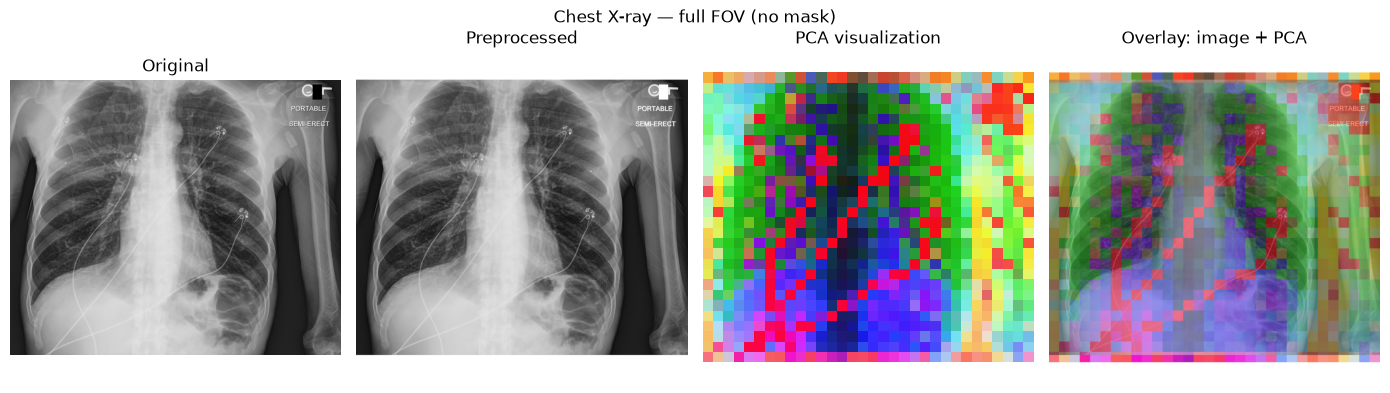

PCA map shape: (32, 32, 3)  visible range: [0.012, 0.995]


In [ ]:
xray_slice = xray.array[0]
print(f"Visualizing the single X-ray frame, shape={xray_slice.shape}")

fig, axes, heatmap = plot_pca_features(
    xray_slice,
    xray_features.patch_embeddings[0],
    original_slice=xray_slice,
    title="Chest X-ray — full FOV (no mask)",
)
plt.show()

finite = heatmap[np.isfinite(heatmap)]
print(f"PCA map shape: {heatmap.shape}  visible range: [{finite.min():.3f}, {finite.max():.3f}]")

## Switching to DINOv3

Point `extract_features` at `configs/dinov3.yaml` (or edit `model.name` / `feature_type` / `n_register_tokens` in your own file). DINOv3 drops CLS + 4 register tokens, so the patch grid still starts at the first image token.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

DINOv3 CLS: (1, 768) patches: (1, 16, 16, 768)
Crop: {'crop_region': (246, 433, 186, 373), 'centroid': (339, 279), 'crop_size': 187, 'padded': False, 'valid_slice_indices': [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]}


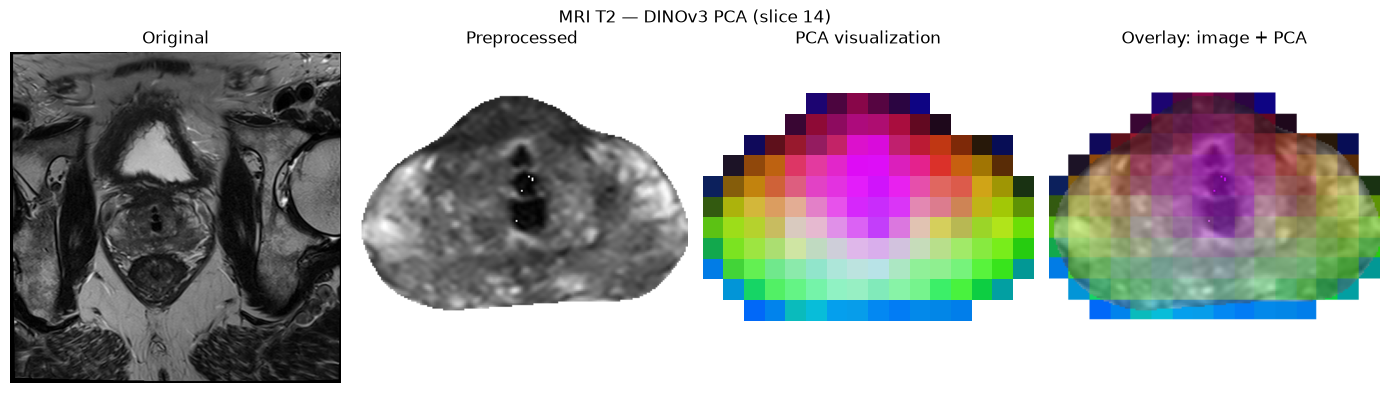

In [ ]:
v3_config = load_config(ROOT / "configs/dinov3.yaml")
v3_config.extraction.crop_to_mask = config.extraction.crop_to_mask
v3_config.extraction.crop_size = config.extraction.crop_size
v3_config.extraction.max_slices = 1
v3_config.extraction.slice_indices = [int(vis_idx)]

v3 = extract_features(MRI_IMAGE, config=v3_config, mask=MRI_MASK)
print("DINOv3 CLS:", v3.cls_embeddings.shape, "patches:", v3.patch_embeddings.shape)
print("Crop:", v3.metadata.get("crop_region"))

fig, axes, _ = plot_pca_features(
    cropped_mri[mri_local_idx],
    v3.patch_embeddings[0],
    original_slice=mri.array[vis_idx],
    mask_slice=cropped_mri_mask[mri_local_idx],
    title=f"MRI T2 — DINOv3 PCA (slice {vis_idx})",
)
plt.show()

## Save

`FeatureResult.save` writes a compressed `.npz` (includes `global_embeddings` as an alias of `cls_embeddings`).

In [ ]:
out_dir = ROOT / "outputs"
mri_path = mri_features.save(out_dir / "mri_t2_dinov2.npz")
ct_path = ct_features.save(out_dir / "ct_dinov2.npz")
xray_path = xray_features.save(out_dir / "xray_dinov2.npz")
print("Wrote", mri_path)
print("Wrote", ct_path)
print("Wrote", xray_path)

Wrote /home/alex_calado/projects/dinomics/outputs/mri_t2_dinov2.npz
Wrote /home/alex_calado/projects/dinomics/outputs/ct_dinov2.npz
Wrote /home/alex_calado/projects/dinomics/outputs/xray_dinov2.npz
